In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

import joblib

In [ ]:
import sys
print(sys.executable)

c:\Users\A.Santhoshi\OneDrive\Desktop\Projectsss\Flood-Prediction\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
print(pd.__version__)

3.0.3


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

import joblib

In [ ]:
dataset = pd.read_excel("flood dataset.xlsx")

In [ ]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [ ]:
dataset.shape

(115, 11)

In [33]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [ ]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [34]:
dataset.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='str')

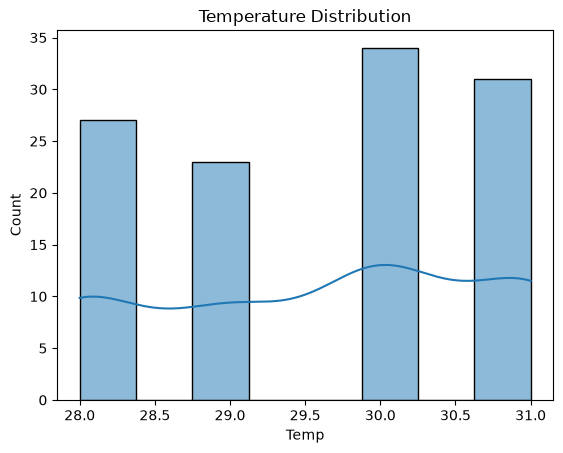

In [ ]:
sns.histplot(dataset["Temp"], kde=True)
plt.title("Temperature Distribution")
plt.show()

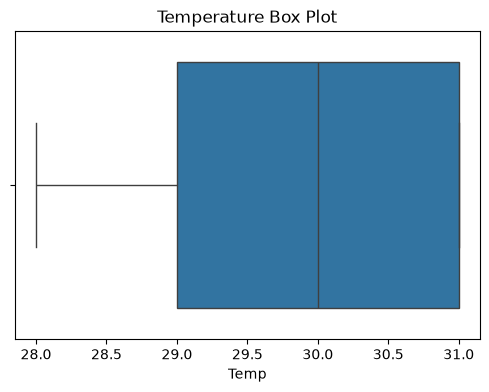

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=dataset["Temp"])
plt.title("Temperature Box Plot")
plt.show()

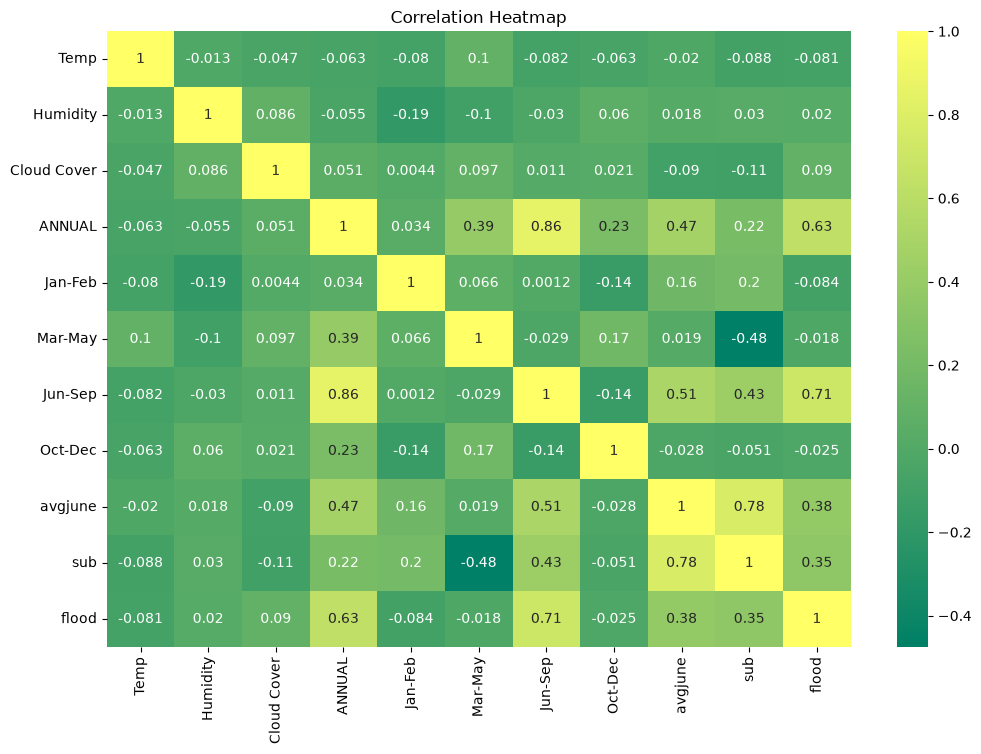

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="summer"
)

plt.title("Correlation Heatmap")

plt.show()

In [38]:
dataset.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

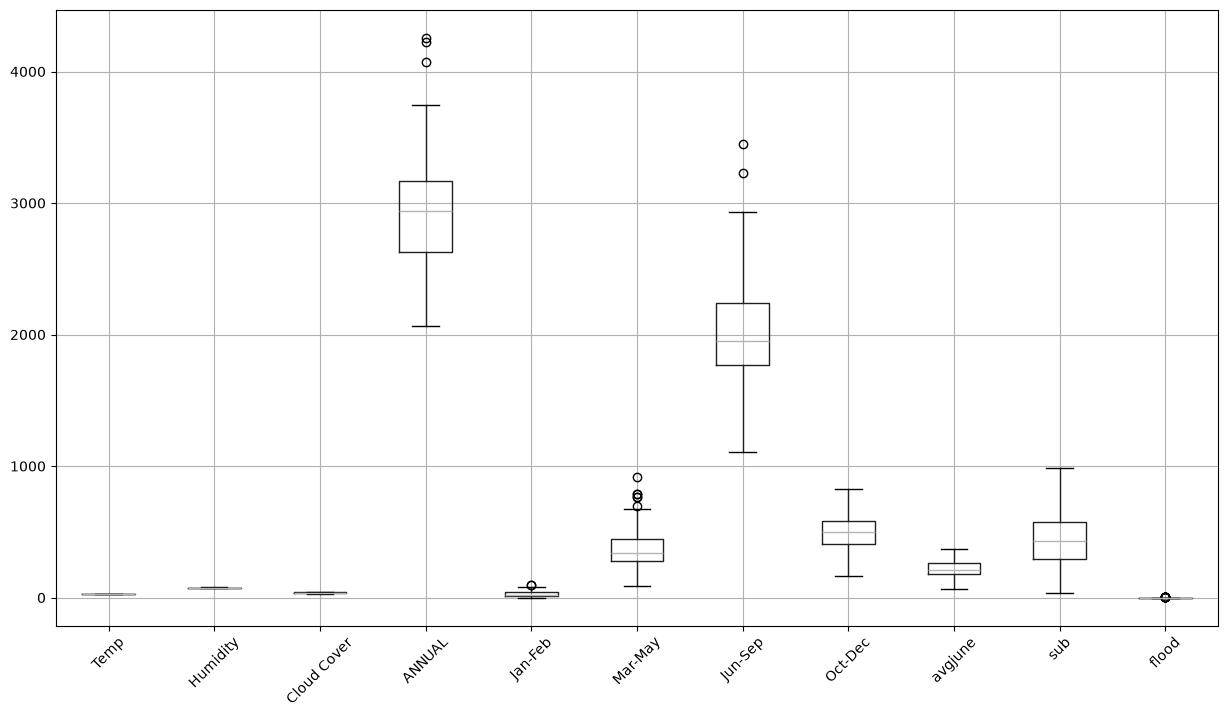

In [ ]:
plt.figure(figsize=(15,8))
dataset.boxplot()
plt.xticks(rotation=45)
plt.show()

In [40]:
X = dataset.iloc[:,2:7].values

In [41]:
y = dataset.iloc[:,10].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=10
)

In [ ]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [ ]:
dtree = DecisionTreeClassifier(random_state=42)

dtree.fit(X_train, y_train)

p1 = dtree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, p1))

Decision Tree Accuracy: 0.9655172413793104


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

p2 = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, p2))

Random Forest Accuracy: 0.9655172413793104


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

p3 = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, p3))

KNN Accuracy: 0.896551724137931


In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

p4 = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, p4))

XGBoost Accuracy: 0.9655172413793104


c:\Users\A.Santhoshi\OneDrive\Desktop\Projectsss\Flood-Prediction\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:15:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("Decision Tree :", accuracy_score(y_test, p1))

print("Random Forest :", accuracy_score(y_test, p2))

print("KNN :", accuracy_score(y_test, p3))

print("XGBoost :", accuracy_score(y_test, p4))

Decision Tree : 0.9655172413793104
Random Forest : 0.9655172413793104
KNN : 0.896551724137931
XGBoost : 0.9655172413793104


In [ ]:
cm = confusion_matrix(y_test, p4)

print(cm)

[[26  0]
 [ 1  2]]


In [ ]:
print(classification_report(y_test, p4))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.67      0.80         3

    accuracy                           0.97        29
   macro avg       0.98      0.83      0.89        29
weighted avg       0.97      0.97      0.96        29



In [ ]:
joblib.dump(xgb, "floods.save")

joblib.dump(sc, "transform.save")

['transform.save']

In [ ]:
import joblib

model = joblib.load("floods.save")
print("Model Loaded Successfully")

scaler = joblib.load("transform.save")
print("Scaler Loaded Successfully")

exit()

Model Loaded Successfully
Scaler Loaded Successfully


: 

In [ ]:
import joblib

model = joblib.load("floods.save")
print("Model Loaded Successfully")

scaler = joblib.load("transform.save")
print("Scaler Loaded Successfully")

exit()

In [ ]:
import pandas as pd
import joblib

model = joblib.load("floods.save")
scaler = joblib.load("transform.save")

data = pd.DataFrame(
    [[40, 3326.6, 9.3, 275.7, 2403.4]],
    columns=[
        "Cloud Cover",
        "ANNUAL",
        "Jan-Feb",
        "Mar-May",
        "Jun-Sep",
    ]
)

scaled = scaler.transform(data)

print(model.predict(scaled))

In [ ]:
import os

print("Current Folder:")
print(os.getcwd())